## Analyzing Failure Modes

In [1]:
%load_ext autoreload
%autoreload 2
import pickle
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from src.mps_utils import to_comp_basis, to_canonical_form
from src.solver import find_nash_eq1
from src.game import get_default_cyclic_players

In [113]:
df = pd.read_pickle(open("data/qpd_6player_ff_chi4/failed_runs/failed_run_20260102_164006_ebf30277-f3b9-4b2e-9e44-c7bb620b59d6.pkl", "rb"))

H = get_default_cyclic_players(L=6)

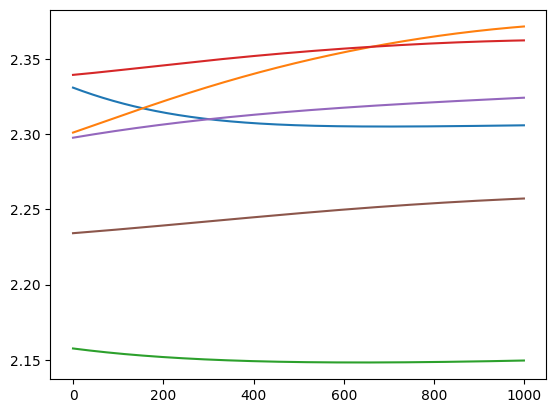

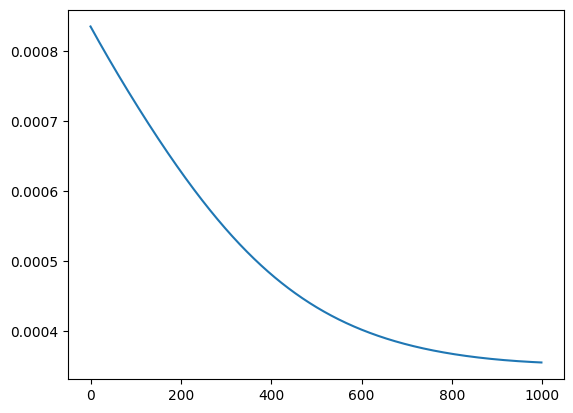

[array([[[-0.187,  0.669]],

       [[-0.702, -0.156]]]), array([[[-0.455,  0.088,  0.304, -0.123],
        [ 0.015,  0.03 ,  0.39 ,  0.701]],

       [[ 0.008,  0.641, -0.493,  0.158],
        [ 0.155,  0.333,  0.452, -0.129]]]), array([[[-0.837,  0.213,  0.001,  0.324, -0.022,  0.009,  0.088,  0.007],
        [ 0.036, -0.376,  0.382,  0.521, -0.46 , -0.174, -0.149, -0.004],
        [-0.133, -0.196, -0.697,  0.083,  0.024, -0.083, -0.071, -0.001],
        [ 0.065,  0.119,  0.091, -0.027, -0.165,  0.052, -0.064,  0.02 ]],

       [[-0.08 , -0.02 , -0.055, -0.003, -0.153,  0.28 ,  0.167, -0.013],
        [ 0.192,  0.271,  0.13 ,  0.185,  0.028, -0.014, -0.109, -0.004],
        [ 0.128,  0.493,  0.132, -0.111, -0.056, -0.346,  0.164, -0.005],
        [-0.842,  0.408,  0.13 , -0.178,  0.01 ,  0.026, -0.116, -0.005]]]), array([[[-0.374,  0.626,  0.245,  0.354],
        [-0.532, -0.397, -0.042,  0.031],
        [ 0.133,  0.096, -0.772,  0.395],
        [-0.38 ,  0.153, -0.203, -0.756],
    

In [114]:
result = df['problematic_result']
plt.plot(result['energy'])
plt.show()

states = result['state']
states_comp_basis = []
for i in range(len(states)):
    state_comp_basis = states[i].reshape(64)
    states_comp_basis.append(state_comp_basis)

# Compute the angle between successive states in the computational basis
states_comp_basis = np.array(states_comp_basis)
# Normalize the states for numerical stability
normed_states = states_comp_basis / np.linalg.norm(states_comp_basis, axis=1, keepdims=True)
# Dot product between each pair of consecutive states (real part only)
overlaps = np.sum(normed_states[1:] * normed_states[:-1], axis=1)
overlaps = np.clip(overlaps, -1, 1)  # avoid domain errors
state_changes = np.arccos(overlaps)
plt.plot(state_changes)
plt.show()

print(result['state_'][0])

In [122]:
init_state = result['state_'][0]

from copy import deepcopy
Psi = deepcopy(init_state)
new_result = find_nash_eq1(
    Psi=Psi,
    H=H,
    use_tqdm=True,
    expl_check_interval=50,
    max_iter=1000,
    expl_threshold=1e-6,
    return_history=True,
    real_strategies=True,
    alpha=0.34
)
print(new_result['energy'][-1])

 90%|█████████ | 900/1000 [00:02<00:00, 374.50it/s]

[2.316 2.171 2.431 2.18  2.256 2.276]


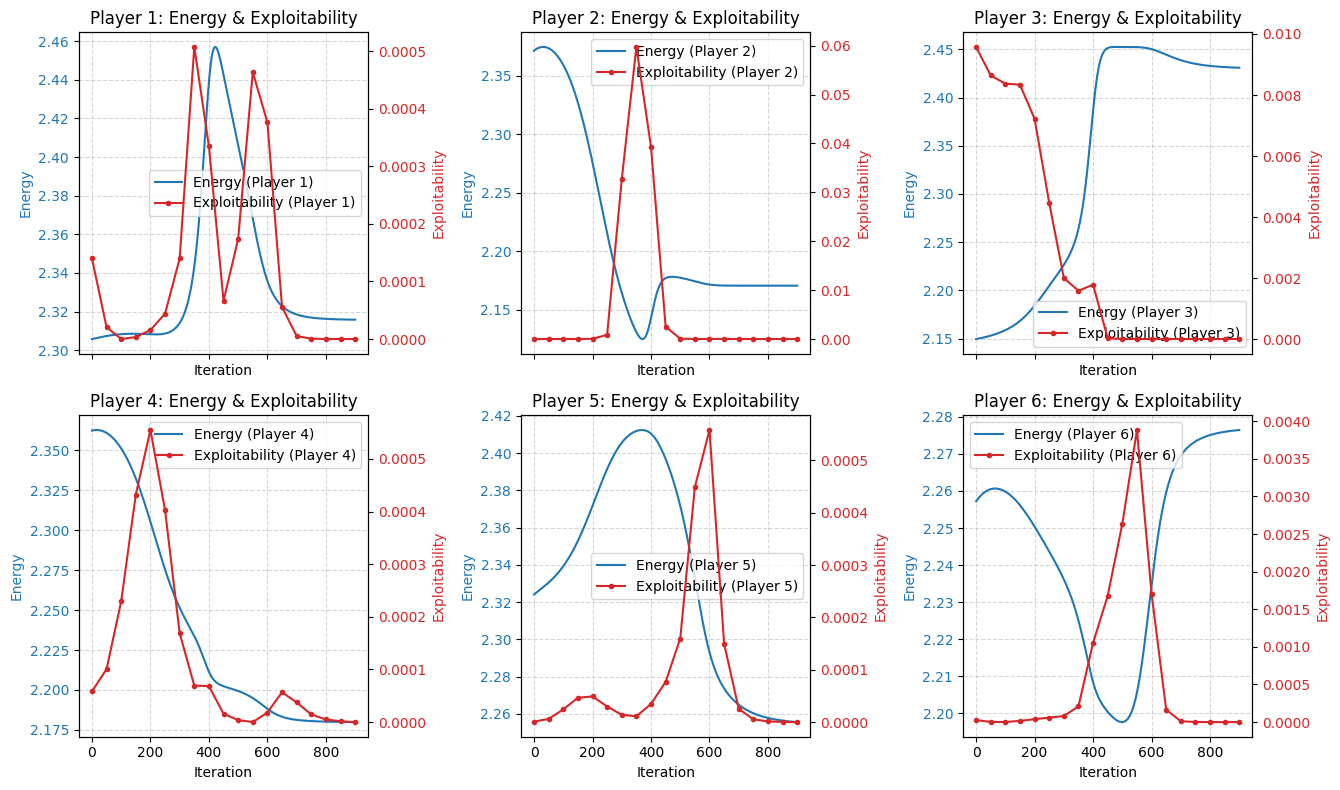

In [123]:
import matplotlib.pyplot as plt

trunc = len(new_result['energy'])
expl_check_interval = 50
num_players = new_result['energy'].shape[1] if len(new_result['energy'].shape) > 1 else 1

# Arrange axes in 2 rows x 3 columns (for up to 6 players)
nrows, ncols = 2, 3
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 4 * nrows), sharex='col')

# Flatten axes for easy indexing
axes_flat = axes.flat if hasattr(axes, 'flat') else [axes]

x_energy = np.arange(trunc)
x_expl = np.arange(0, trunc, expl_check_interval)
color_energy = "tab:blue"
color_expl = "tab:red"

for i in range(num_players):
    ax = axes_flat[i]
    # Overlay energy and exploitability on same subplot with two y axes

    # Energy
    if num_players > 1:
        energy_y = new_result['energy'][:trunc, i]
        expl_y = new_result['expl'][:len(x_expl), i]
    else:
        energy_y = new_result['energy'][:trunc]
        expl_y = new_result['expl'][:len(x_expl)]

    ln1 = ax.plot(x_energy, energy_y, label=f'Energy (Player {i+1})', color=color_energy)
    ax.set_ylabel('Energy', color=color_energy)
    ax.tick_params(axis='y', labelcolor=color_energy)
    ax.set_xlabel('Iteration')
    ax.set_title(f'Player {i+1}: Energy & Exploitability')
    ax.grid(True, linestyle="--", alpha=0.5)

    # Exploitability (secondary y-axis)
    ax2 = ax.twinx()
    ln2 = ax2.plot(x_expl, expl_y, label=f'Exploitability (Player {i+1})', color=color_expl, linestyle='-', marker='.')
    ax2.set_ylabel('Exploitability', color=color_expl)
    # ax2.set_yscale('log')
    ax2.tick_params(axis='y', labelcolor=color_expl)

    # Legend handling for two lists of handles/labels
    lns = ln1 + ln2
    labels = [l.get_label() for l in lns]
    ax.legend(lns, labels, loc='best')

# Hide unused axes if num_players < nrows*ncols
for j in range(num_players, nrows * ncols):
    fig.delaxes(axes_flat[j])

plt.tight_layout()
plt.show()


In [30]:
new_result.keys()

dict_keys(['nash_state', 'nash_equilibrium', 'energy', 'state', 'state_', 'num_iters', 'expl'])

## Failure mode for non-commutative payoffs

In [136]:
df = pickle.load(open("data/qpd_3player_nocomm/failed_runs/failed_run_20260102_213751_0e514afe-43c0-4452-96ef-02fbd899ac5b.pkl", "rb"))

dict_keys(['problematic_result', 'current_state', 'baseline_result', 'metric_logs_so_far', 'iteration', 'num_perturbations', 'metadata'])

In [155]:
from src.game import get_default_cyclic_players, get_perturbed_H_QPD, H_QPD

perturbed_H_QPD = get_perturbed_H_QPD(eps=1)
Hs = get_default_cyclic_players(L=3, Hs=perturbed_H_QPD)



[array([[[[[[ 3.485,  0.154],
           [ 0.154,  0.   ]],

          [[-0.05 , -0.131],
           [-0.131,  0.   ]]],


         [[[ 0.154,  1.708],
           [ 0.   ,  0.154]],

          [[-0.047, -0.242],
           [ 0.   , -0.131]]]],



        [[[[ 0.154,  0.   ],
           [ 1.708,  0.154]],

          [[-0.047,  0.   ],
           [-0.242, -0.131]]],


         [[[ 0.   ,  0.154],
           [ 0.154, -0.068]],

          [[ 0.   , -0.047],
           [-0.047, -0.433]]]]],




       [[[[[-0.05 , -0.047],
           [-0.047,  0.   ]],

          [[ 4.9  ,  0.056],
           [ 0.056,  0.   ]]],


         [[[-0.131, -0.242],
           [ 0.   , -0.047]],

          [[ 0.056,  2.945],
           [ 0.   ,  0.056]]]],



        [[[[-0.131,  0.   ],
           [-0.242, -0.047]],

          [[ 0.056,  0.   ],
           [ 2.945,  0.056]]],


         [[[ 0.   , -0.131],
           [-0.131, -0.433]],

          [[ 0.   ,  0.056],
           [ 0.056,  0.99 ]]]]]]), array([[[[[[ 

In [165]:
from src.mps_utils import get_rand_mps

Psi = get_rand_mps(L=6, chi=9, dtype=np.float32)
print([psi.shape for psi in Psi])

[(2, 1, 2), (2, 2, 4), (2, 4, 8), (2, 8, 4), (2, 4, 2), (2, 2, 1)]


## 6 player clean QPD

In [193]:
import pickle
import pandas as pd
import numpy as np
from src.mps_utils import to_comp_basis

df = pickle.load(open("data/qpd6/chi_9/qpd6_20260103_081415_c7b5c2b6.pkl", "rb"))
df = pd.DataFrame(df['metric_logs'])
df['welfare'] = df['energy'].apply(np.sum)
df['state_'] = df['state'].apply(to_comp_basis)

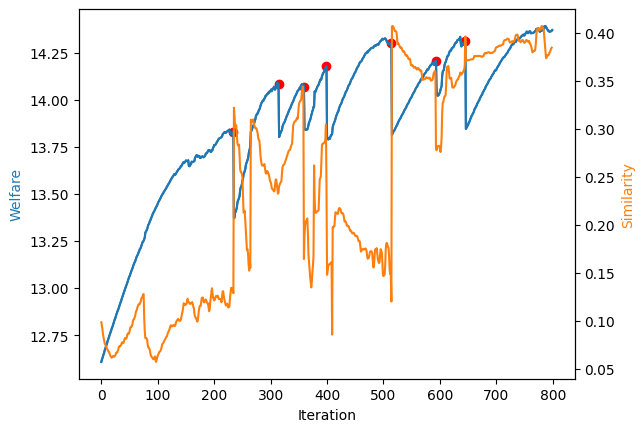

In [200]:
import matplotlib.pyplot as plt

fig, ax1 = plt.subplots()
W = df['welfare']
plt.plot(W)

# Assuming 'y_values' is your data array
# Calculate the difference between consecutive points
diffs = np.diff(W)
threshold = -0.1
# Find indices where the difference is lower (more negative) than the threshold
drop_indices = np.where(diffs < threshold)[0]
plt.scatter(drop_indices, W[drop_indices], color='red')



# Avoid repeated sampling by using replace=False
available_indices = np.array(list(set(range(len(df))) - set(drop_indices)))
rand_indices = np.random.choice(available_indices, size=10, replace=False)
states_rand = df['state_'][rand_indices].tolist()
states_after_rand = df['state_'][rand_indices+1].tolist()

states_at_drops = df['state_'][drop_indices].tolist()
states_after_drops = df['state_'][drop_indices+1].tolist()

similarities = [np.abs(np.dot(s1, s2)) for s1, s2 in zip(df['state_'][:-1], df['state_'][1:])]


ax2 = ax1.twinx()
ax1.plot(W, label='Welfare', color='tab:blue')
ax2.plot(similarities, label='State Similarity', color='tab:orange')

ax1.set_xlabel('Iteration')
ax1.set_ylabel('Welfare', color='tab:blue')
ax2.set_ylabel('Similarity', color='tab:orange')

plt.show()


## Case Study

In [10]:
# Without gradient normalization and clipping
demo_chi5_trail = "data/qpd6/chi_5/qpd6_20260103_084031_5dadcc8d.pkl"
new_gradclip_trail = "data/tests/qpd6_20260104_093131_fcea6c7e.pkl"
def get_similarities(filename):
    df = pickle.load(open(filename, "rb"))
    df = pd.DataFrame(df['metric_logs'])
    df['welfare'] = df['energy'].apply(np.sum)
    df['state_'] = df['state'].apply(to_comp_basis)
    similarities = [np.abs(np.dot(s1, s2)) for s1, s2 in zip(df['state_'][:-1], df['state_'][1:])]
    fig, ax1 = plt.subplots()
    ax2 = ax1.twinx()
    ax1.plot(df['welfare'], color='tab:blue', label='Welfare')
    ax2.plot(similarities, color='tab:orange', label='Similarity')

    ax1.set_ylabel('Welfare', color='tab:blue')
    ax2.set_ylabel('Similarity', color='tab:orange')
    ax1.set_xlabel('Iteration')
    plt.show()

In [ ]:
get_similarities(new_gradclip_trail)

## Gradient Stability vs Perturbation Size Diagnostic

In [22]:
# Load a training run to get a state for testing
import pickle
import numpy as np
from src.mps_utils import to_canonical_form
from src.solver import batch_perturb, find_nash_eq1_with_retry, estimate_gradient_ols
from src.game import get_default_cyclic_players

# You can change this to any of your training runs
# Using the 6-player run you were analyzing
df = pickle.load(open("data/qpd6/chi_9/qpd6_20260103_081415_c7b5c2b6.pkl", "rb"))

# Pick a state where you see large gradients (or just use a random one)
# You can change this index to test different points in your training
test_idx = 396  # This is around where you showed the gradient clipping in your output
Psi_test = df['metric_logs'][test_idx]['state']
Psi_test = to_canonical_form(Psi_test, form='B')

# Get the Hamiltonian
L = len(Psi_test)
H = get_default_cyclic_players(L=L)

print(f"Testing state at iteration {test_idx}")
print(f"Number of players: {L}")
print(f"Bond dimensions: {[psi.shape for psi in Psi_test]}")

Testing state at iteration 396
Number of players: 6
Bond dimensions: [(2, 1, 2), (2, 2, 4), (2, 4, 8), (2, 8, 4), (2, 4, 2), (2, 2, 1)]


In [19]:
def test_perturbation_size(Psi, H, eps_values, site=0, num_perturbations=10, 
                          subroutine_max_iter=1000, subroutine_lr=0.03, 
                          max_subroutine_lr=1.0):
    """
    Test how gradient estimation changes with different perturbation sizes.
    
    Returns:
        results: dict with keys 'eps_values', 'grad_norms', 'welfare_changes', 
                 'success_rates', 'grad_estimates'
    """
    results = {
        'eps_values': eps_values,
        'grad_norms': [],
        'welfare_changes': [],
        'success_rates': [],
        'grad_estimates': [],
        'baseline_welfare': None
    }
    
    # First, find the Nash equilibrium of the baseline state
    print("Finding baseline Nash equilibrium...")
    baseline_result, baseline_success, _ = find_nash_eq1_with_retry(
        Psi, H,
        max_iter=subroutine_max_iter,
        base_alpha=subroutine_lr,
        max_alpha=max_subroutine_lr,
        max_retries=20,
        expl_check_interval=50,
        expl_maxiter=60,
        real_strategies=True,
        return_history=False
    )
    
    if not baseline_success:
        print("Warning: Baseline NE not found!")
        return None
    
    baseline_welfare = np.sum(baseline_result['energy'])
    results['baseline_welfare'] = baseline_welfare
    print(f"Baseline welfare: {baseline_welfare:.4f}")
    
    # Test each perturbation size
    for eps in eps_values:
        print(f"\nTesting eps={eps:.4f}...")
        
        # Generate perturbed states
        Psi_batch, original_param, batch_perturbed_param = batch_perturb(
            Psi, batch_size=num_perturbations, lr=eps, site=site, method='unitary'
        )
        
        energy_diffs = []
        valid_param_diffs = []
        all_param_diffs = np.array(batch_perturbed_param) - np.array(original_param)
        
        num_success = 0
        
        # Find Nash equilibrium for each perturbation
        for j in range(num_perturbations):
            Psi_ = [psi[j] for psi in Psi_batch]
            
            result_, success, _ = find_nash_eq1_with_retry(
                Psi_, H,
                max_iter=subroutine_max_iter,
                base_alpha=subroutine_lr,
                max_alpha=max_subroutine_lr,
                max_retries=20,
                expl_check_interval=50,
                expl_maxiter=60,
                real_strategies=True,
                return_history=False
            )
            
            if success:
                num_success += 1
                energy_diff = np.sum(result_['energy']) - baseline_welfare
                energy_diffs.append(energy_diff)
                valid_param_diffs.append(all_param_diffs[j])
        
        success_rate = num_success / num_perturbations
        results['success_rates'].append(success_rate)
        
        print(f"  Success rate: {num_success}/{num_perturbations} ({success_rate*100:.1f}%)")
        
        if len(energy_diffs) > 0:
            # Estimate gradient
            grad_est = estimate_gradient_ols(
                np.array(valid_param_diffs), 
                np.array(energy_diffs)
            )
            
            grad_norm = np.linalg.norm(grad_est)
            mean_welfare_change = np.mean(energy_diffs)
            
            results['grad_norms'].append(grad_norm)
            results['welfare_changes'].append(mean_welfare_change)
            results['grad_estimates'].append(grad_est)
            
            print(f"  Gradient norm: {grad_norm:.4f}")
            print(f"  Mean welfare change: {mean_welfare_change:.4f}")
        else:
            print(f"  All perturbations failed!")
            results['grad_norms'].append(np.nan)
            results['welfare_changes'].append(np.nan)
            results['grad_estimates'].append(None)
    
    return results

In [23]:
# Run the diagnostic test
# Test a range of perturbation sizes from very small to the ones you typically use
eps_values = [0.001, 0.003, 0.005, 0.01, 0.02, 0.05]

# Choose which site to test (you can change this)
# test_site = test_idx % (L - 1)  # Same site pattern as in your training
test_site = 2

print(f"Testing site: {test_site}\n")

# Run the test (this will take a few minutes depending on L and number of perturbations)
diagnostic_results = test_perturbation_size(
    Psi_test, 
    H, 
    eps_values, 
    site=test_site,
    num_perturbations=10,  # You can increase this for more reliable statistics
    subroutine_max_iter=1000,
    subroutine_lr=0.03,
    max_subroutine_lr=1.0
)

Testing site: 2

Finding baseline Nash equilibrium...
Baseline welfare: 14.1606

Testing eps=0.0010...
  Success rate: 10/10 (100.0%)
  Gradient norm: 0.0007
  Mean welfare change: 0.0001

Testing eps=0.0030...
  Success rate: 10/10 (100.0%)
  Gradient norm: 0.0021
  Mean welfare change: 0.0001

Testing eps=0.0050...
  Success rate: 10/10 (100.0%)
  Gradient norm: 0.0036
  Mean welfare change: -0.0003

Testing eps=0.0100...
  Success rate: 10/10 (100.0%)
  Gradient norm: 0.0071
  Mean welfare change: 0.0002

Testing eps=0.0200...
  Success rate: 10/10 (100.0%)
  Gradient norm: 0.0113
  Mean welfare change: 0.0012

Testing eps=0.0500...
Retry 1/20 with higher learning rate: 0.0785
Retry 2/20 with higher learning rate: 0.1270
Success on retry 3 with LR 0.1270
Retry 1/20 with higher learning rate: 0.0785
Retry 2/20 with higher learning rate: 0.1270
Success on retry 3 with LR 0.1270
Retry 1/20 with higher learning rate: 0.0785
Success on retry 2 with LR 0.0785
  Success rate: 10/10 (100.0%

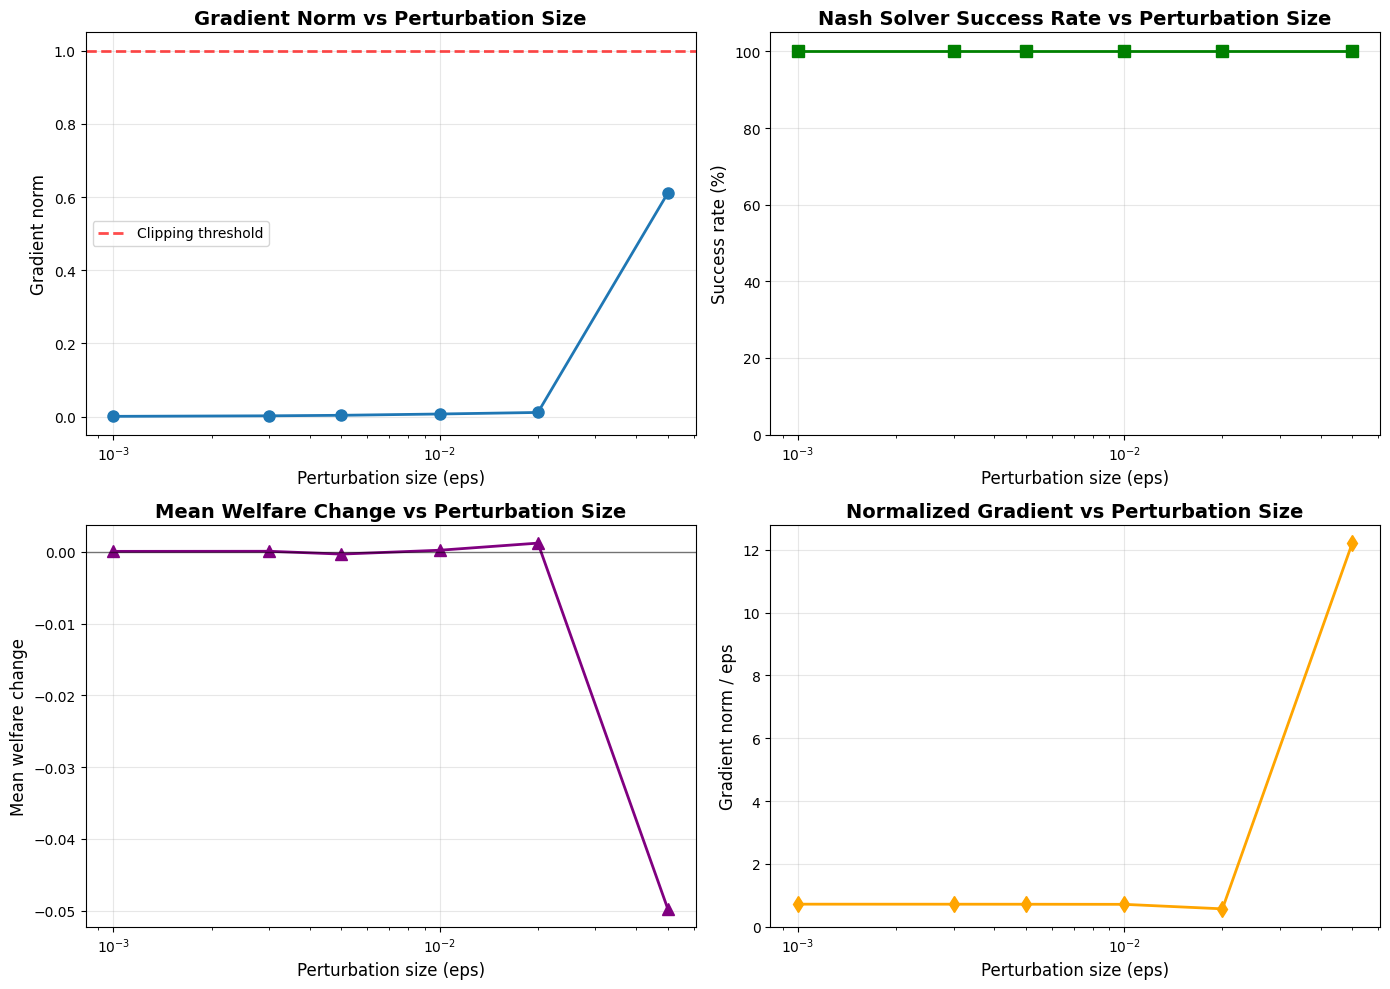


SUMMARY
Baseline welfare: 14.1606

eps=0.0010:
  Gradient norm: 0.0007
  Success rate: 100.0%
  Mean welfare change: 0.0001

eps=0.0030:
  Gradient norm: 0.0021
  Success rate: 100.0%
  Mean welfare change: 0.0001

eps=0.0050:
  Gradient norm: 0.0036
  Success rate: 100.0%
  Mean welfare change: -0.0003

eps=0.0100:
  Gradient norm: 0.0071
  Success rate: 100.0%
  Mean welfare change: 0.0002

eps=0.0200:
  Gradient norm: 0.0113
  Success rate: 100.0%
  Mean welfare change: 0.0012

eps=0.0500:
  Gradient norm: 0.6106
  Success rate: 100.0%
  Mean welfare change: -0.0497



In [24]:
# Visualize the results
import matplotlib.pyplot as plt

if diagnostic_results is not None:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    eps_vals = diagnostic_results['eps_values']
    
    # Plot 1: Gradient norm vs perturbation size
    ax1 = axes[0, 0]
    ax1.plot(eps_vals, diagnostic_results['grad_norms'], 'o-', linewidth=2, markersize=8)
    ax1.set_xlabel('Perturbation size (eps)', fontsize=12)
    ax1.set_ylabel('Gradient norm', fontsize=12)
    ax1.set_title('Gradient Norm vs Perturbation Size', fontsize=14, fontweight='bold')
    ax1.grid(True, alpha=0.3)
    ax1.set_xscale('log')
    
    # Add horizontal line at your clipping threshold
    ax1.axhline(y=1.0, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Clipping threshold')
    ax1.legend()
    
    # Plot 2: Success rate vs perturbation size
    ax2 = axes[0, 1]
    success_pct = [s*100 for s in diagnostic_results['success_rates']]
    ax2.plot(eps_vals, success_pct, 's-', linewidth=2, markersize=8, color='green')
    ax2.set_xlabel('Perturbation size (eps)', fontsize=12)
    ax2.set_ylabel('Success rate (%)', fontsize=12)
    ax2.set_title('Nash Solver Success Rate vs Perturbation Size', fontsize=14, fontweight='bold')
    ax2.grid(True, alpha=0.3)
    ax2.set_xscale('log')
    ax2.set_ylim([0, 105])
    
    # Plot 3: Mean welfare change vs perturbation size
    ax3 = axes[1, 0]
    ax3.plot(eps_vals, diagnostic_results['welfare_changes'], '^-', linewidth=2, markersize=8, color='purple')
    ax3.set_xlabel('Perturbation size (eps)', fontsize=12)
    ax3.set_ylabel('Mean welfare change', fontsize=12)
    ax3.set_title('Mean Welfare Change vs Perturbation Size', fontsize=14, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    ax3.set_xscale('log')
    ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    
    # Plot 4: Gradient norm / eps (normalized gradient)
    ax4 = axes[1, 1]
    normalized_grads = [g/e for g, e in zip(diagnostic_results['grad_norms'], eps_vals)]
    ax4.plot(eps_vals, normalized_grads, 'd-', linewidth=2, markersize=8, color='orange')
    ax4.set_xlabel('Perturbation size (eps)', fontsize=12)
    ax4.set_ylabel('Gradient norm / eps', fontsize=12)
    ax4.set_title('Normalized Gradient vs Perturbation Size', fontsize=14, fontweight='bold')
    ax4.grid(True, alpha=0.3)
    ax4.set_xscale('log')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print("\n" + "="*60)
    print("SUMMARY")
    print("="*60)
    print(f"Baseline welfare: {diagnostic_results['baseline_welfare']:.4f}\n")
    
    for i, eps in enumerate(eps_vals):
        print(f"eps={eps:.4f}:")
        print(f"  Gradient norm: {diagnostic_results['grad_norms'][i]:.4f}")
        print(f"  Success rate: {diagnostic_results['success_rates'][i]*100:.1f}%")
        print(f"  Mean welfare change: {diagnostic_results['welfare_changes'][i]:.4f}")
        print()

### How to Interpret These Results

**What to look for:**

1. **Gradient Norm (top left)**: 
   - If gradient norm **increases sharply** with larger eps → large gradients are artifacts of basin-jumping
   - If gradient norm is **relatively stable** across eps values → true gradient signal
   - The red dashed line shows your clipping threshold (1.0)

2. **Success Rate (top right)**:
   - Lower success rate means more perturbations jump to different basins during Nash solving
   - If success rate drops significantly at larger eps → those eps values cause too much basin-jumping

3. **Mean Welfare Change (bottom left)**:
   - Should be relatively smooth and consistent across eps values if gradient is reliable
   - Large discontinuities indicate basin-jumping in the perturbations

4. **Normalized Gradient (bottom right)**:
   - For a true smooth gradient, this should be approximately constant (independent of eps)
   - If this varies wildly with eps → gradient estimate is unreliable

**Recommended action based on results:**
- If small eps (e.g., 0.001-0.005) gives stable gradients → use smaller eps in your training
- If all eps values show unstable gradients → the Nash manifold may be fundamentally non-smooth
- Compare gradient norms at different welfare values (run this diagnostic at multiple `test_idx` values)